# EDA Part 1 (ml.m5.12xlarge)

In [1]:
import os
import pandas as pd
import numpy as np
import functions as func

### Constants

In [2]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')
str_step = os.getcwd().split('/')[-1]
print(f'Step: {str_step}')
str_dirname_output = './output'

str_id = 'uniqueid'
str_datecol = 'applicationdate__app'
str_target = 'target'

list_cols_id = [
    str_id,
    str_datecol,
    str_target,
]

Project: 20231010-gen-xii
Step: 02_eda_pt_1


### Output

In [3]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

### Import data

In [4]:
%%time

# import
str_filename = 'df_raw.gzip'
str_uri = f's3://{str_project}/03_pricing_lgd/01_data_prep/01_data_collection/output/{str_filename}'
# read from s3
df = pd.read_parquet(str_uri)
# replace
df.replace(['NaN','nan'], np.nan, inplace=True)

# show
df

<timed exec>:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


CPU times: user 2.18 s, sys: 3.43 s, total: 5.61 s
Wall time: 1.42 s


,dtmstampcreation__base,dtmapproved__base,dtmdeclined__base,observationdate__base,analyticsmatchkey__base,decision_dte__base,booked__base,acct_typ_cde__base,open_dte__base,curr_bal_amt__base,...,dti__app,pti__app,bitservicecontract__app,fltadvance__app,strvehicletype__app,bitgap__app,dealerstampcreation__app,RunningNetLoss,bitTarget24Months,target
11,20181120.0,20181120.0,NaN,201810.0,106347.0,2018-11-20,1.0,AU,2018-11-29,NaN,...,0.330848,0.107492,1,1.084734,suv,1,2012-02-10 13:48:47.720,20387.06,1,0.985462
12,20181120.0,20181120.0,NaN,201810.0,106347.0,2018-11-20,1.0,AU,2018-11-29,NaN,...,0.330848,0.107492,1,1.084734,suv,1,2012-02-10 13:48:47.720,20387.06,1,0.985462
19,20181017.0,20181017.0,NaN,201810.0,39394.0,2018-10-17,1.0,AU,2018-10-17,6934.0,...,0.814385,0.341774,1,1.005341,auto,0,2006-04-16 10:50:55.000,4442.31,1,0.272984
20,20181017.0,20181017.0,NaN,201810.0,39394.0,2018-10-17,1.0,AU,2018-10-17,6934.0,...,0.814385,0.341774,1,1.005341,auto,0,2006-04-16 10:50:55.000,4442.31,1,0.272984
21,20181017.0,20181017.0,NaN,201810.0,34747.0,2018-10-17,1.0,AU,2018-10-17,17428.0,...,0.380302,0.149874,0,1.253794,auto,0,2003-07-08 14:32:29.097,9584.90,1,0.434160
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
186164,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.203666,0.100599,0,1.210315,truck,0,2013-04-02 15:33:30.193,28198.75,1,0.939958
186165,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.358319,0.113501,1,1.176435,auto,1,2014-09-09 16:07:25.123,13195.01,1,0.754292
186166,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.334282,0.121807,0,1.150000,auto,1,2012-11-05 16:48:22.563,7251.90,1,0.543776
186168,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.419962,0.109622,0,1.249284,auto,0,2011-06-21 16:14:20.870,11811.67,1,0.981076


### Get data frame information

In [5]:
%%time

# get df info
str_filename = 'dict_df_info.json'
func.get_df_info(
    df=df, 
    str_datecol=str_datecol, 
    str_dirname_output=str_dirname_output, 
    str_filename=str_filename,
)
print('')

{'date_max': '2019-12-31 14:06:40.040000',
 'date_min': '2013-10-01 07:28:54.833000',
 'flt_mean_target': 0.6020918357059728,
 'flt_propna': 0.21873376598460767,
 'int_ncols': 2492,
 'int_nrows': 20498,
 'int_obs_total': 51081016}

CPU times: user 135 ms, sys: 35.1 ms, total: 170 ms
Wall time: 152 ms


### Get descriptives

In [6]:
%%time

str_filename = 'df_descriptives.csv'
list_cols = [col for col in df.columns if col not in list_cols_id]
df_tmp = func.get_descriptives_by_column(
    df=df[list_cols], 
    str_dirname_output=str_dirname_output, 
    str_filename=str_filename,
)

# show
df_tmp

# save memory
del df_tmp

100%|██████████| 2489/2489 [00:07<00:00, 320.42it/s]


CPU times: user 7.67 s, sys: 380 ms, total: 8.05 s
Wall time: 7.96 s


### Get descriptives by ID columns

In [7]:
%%time

str_filename = 'df_descriptives_id.csv',
df_tmp = func.get_descriptives_by_column(
    df=df[list_cols_id], 
    str_dirname_output=str_dirname_output, 
    str_filename=str_filename,
)

# show
df_tmp

# save memory
del df_tmp

100%|██████████| 3/3 [00:00<00:00, 231.38it/s]

CPU times: user 17.1 ms, sys: 698 µs, total: 17.8 ms
Wall time: 17 ms


### Plot proportion ```NaN```

CPU times: user 173 ms, sys: 11.2 ms, total: 184 ms
Wall time: 204 ms


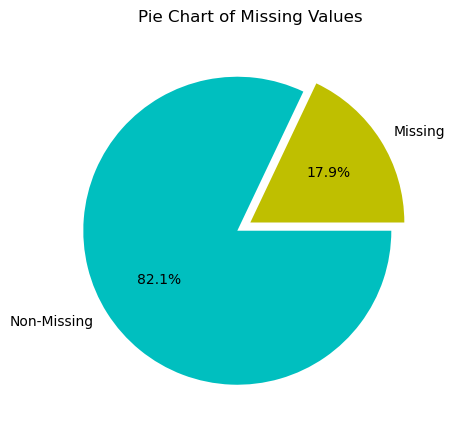

In [8]:
%%time

# plot proportion NaN
try:
    str_filename = 'plt_prop_nan.png',
    func.plot_proportion_nan(
        df=df,
        str_dirname_output=str_dirname_output,
        str_filename=str_filename,
    )
except:
    pass

### Plot data type frequency

100%|██████████| 2492/2492 [00:00<00:00, 17378.95it/s]


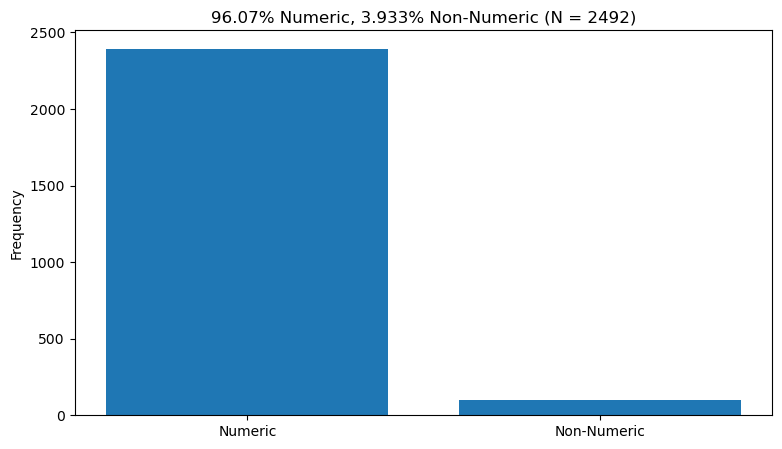

CPU times: user 401 ms, sys: 5.87 ms, total: 407 ms
Wall time: 406 ms


In [9]:
%%time

# plot data type frequency
str_filename = 'plt_dtype.png'
func.plot_data_type_frequency(
    df=df,
    str_dirname_output=str_dirname_output,
    str_filename=str_filename,
)

### Plot target

/home/ec2-user/SageMaker/20231010_gen_xii/03_pricing_lgd/01_data_prep/02_eda_pt_1/functions.py:203: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(list(ser_target), ax=ax)


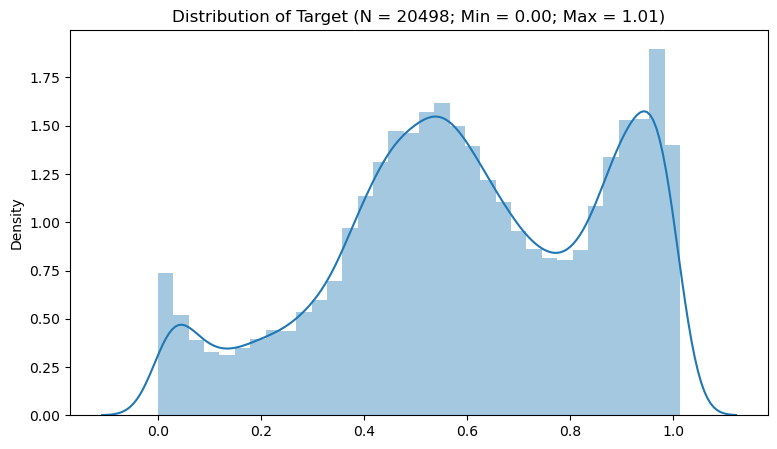

CPU times: user 2.41 s, sys: 78.8 ms, total: 2.49 s
Wall time: 476 ms


In [10]:
%%time

# plot target
str_filename = 'plt_target.png'
func.plot_target(
    ser_target=df[str_target],
    str_dirname_output=str_dirname_output,
    str_filename=str_filename,
)

## Write ```README.md``` to local drive

In [11]:
%%writefile README.md

A dictionary of data frame information is available [here](output/dict_df_info.json).

A data frame of descriptive statistics sorted descending by proportion missing by column is available [here](output/df_descriptives.csv).

A data frame of descriptive statistics sorted descending by proportion missing by ID column is available [here](output/df_descriptives_ids.csv).

A plot of percent missing overall in ```df_raw``` is shown below:

<p align="center"><img src="./output/plt_prop_nan.png" width=50% height=50% /></p>

A plot of data type frequency is shown below:
    
<p align="center"><img src="./output/plt_dtype.png" width=50% height=50% /></p>

Plots of the targets are shown below:
    
<p align="center"><img src="./output/plt_target.png" width=50% height=50% /></p>

Overwriting README.md
